<h4> Exercise1:  Codon Frequency Clustering
    
- Consider the codon log frequencies in selected plants, viruses, and bacteria.

- Use the K-means algorithm with $k=3$ to divide the data into 3 clusters.

- Evaluate how well the predicted clusters correspond to the actual organism information.
   

c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\

0.5128732019823522


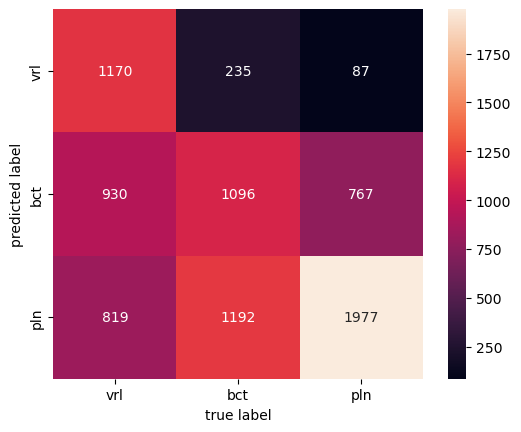

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 

df = pd.read_csv("codon_usage.csv")
df = df[df['Kingdom'].isin(['pln', 'vrl','bct'])]
df['UGA;'] = df['UGA;'].str.replace(';', '')
y = df["Kingdom"]
y = y.to_numpy()
X = df.drop(columns=["Kingdom","DNAtype", "SpeciesID", "Ncodons", "SpeciesName"]).apply(pd.to_numeric, errors='coerce').apply(lambda x: np.log(x + 0.001))
X = X.to_numpy()

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X) #fittuje i daje etykiete

#labelujemy kolory
from collections import Counter
labels = np.full_like(clusters, "", dtype=object) #lista pustych stringów

for i in range(3):
    mask = (clusters == i)
    labels[mask] = Counter(y[mask]).most_common()[0][0] 

#score
from sklearn.metrics import accuracy_score
print(accuracy_score(y, labels))

#heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(y, labels)
sns.heatmap(mat.T, square = True, annot = True, fmt = "d", cbar = True,
            xticklabels = list(set(y)),
            yticklabels = list(set(y)))

plt.xlabel("true label")
plt.ylabel("predicted label")
plt.show()  

#comment, accuracy is around 50 so its not great but better than random

<h4> Exercise2: Consider the Breast Cancer dataset. Using the BIC as the evaluation criterion, test different numbers of clusters to which the data can be partitioned using the K-means algorithm. What is the optimal value of k? Comment on the results

In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign
X = df.drop("target", axis = 1)

c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\kajaw\miniconda3\envs\Pbioinf1.2\Lib\site-packages\sklearn\cluster\_kmeans.p

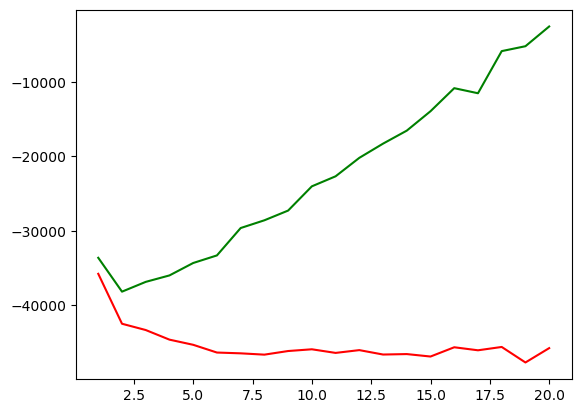

In [4]:
from sklearn.mixture import GaussianMixture

def AIC(X, k):
    gmm = GaussianMixture(n_components=k, init_params='kmeans')
    gmm.fit(X)
    return gmm.aic(X)

def BIC(X, k): 
    gmm = GaussianMixture(n_components=k, init_params='kmeans')
    gmm.fit(X)
    return gmm.bic(X)

BIC_list = []
AIC_list = []

for i in range(1, 21):
    kmeans = KMeans(n_clusters = i, random_state=3)
    clusters = kmeans.fit(X) #fituje i daje etykiete
    BIC_list.append(BIC(X,i))
    AIC_list.append(AIC(X,i))

plt.plot(range(1,21), AIC_list, c = "red")
plt.plot(range(1,21), BIC_list, c = "green") #bic lepsze

plt.show()

#mioptimal value = 2, mathches the data (zdrowy/chory)
    

<h4> Exercise3:  Influenza Virus Sequence Analysis

- Open the file "influenza viruses" containing nucleotide sequences of various influenza virus types.

- Represent each sequence as a vector of 4-mer frequencies, resulting in a matrix X.

- Compute the standard deviation for each 4-mer across virus groups. Select the two mers with the highest variation between groups and visualize the data, using colors to indicate virus types. Make a comment on it.

- Experiment with different numbers of top discriminative k-mers. Use these features to perform hierarchical clustering and attempt to group viruses of the same type together.

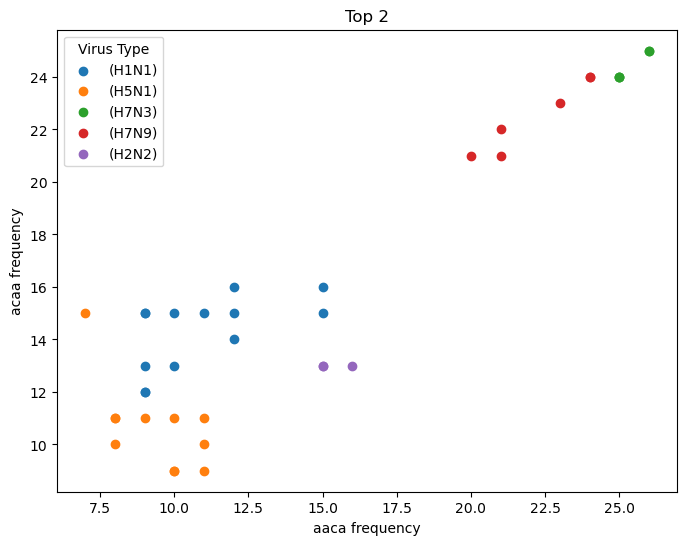

In [87]:
with open('influenza_viruses', 'r') as file:
    virus = file.readlines()

lab = [virus[i].strip().replace('>', '') for i in range(0, len(virus), 2)] #get virus name
virus_type =[i[-6:] for i in lab] #get virus type
seq = [virus[i].strip() for i in range(1, len(virus), 2)] #get virus seq

def kmers(seq, k=4):
    d = {}
    N = len(seq)
    for i in range(N - k + 1):
        mer = seq[i:(i + k)]
        if mer not in d.keys():
            d[mer] = 1
        else:
            d[mer] += 1
    return d

#df of kmer freq
kmerki = [kmers(s) for s in seq]
kmerki = pd.DataFrame(kmerki).fillna(0) #change na to 0
kmerki['virus_type'] = virus_type #add virus type
grouped = kmerki.groupby('virus_type').mean() #group by virus type
stds = grouped.std() #get stds for each k-mer
top2 = stds.sort_values(ascending=False).head(2).index.to_list()

#plot
plt.figure(figsize=(8, 6))

# Plot each virus type separately
for virus_type in kmerki['virus_type'].unique():
    subset = kmerki[kmerki['virus_type'] == virus_type]
    plt.scatter(
        subset[top2[0]],
        subset[top2[1]],
        label=virus_type
    )

plt.xlabel(f'{top2[0]} frequency')
plt.ylabel(f'{top2[1]} frequency')
plt.title('Top 2')
plt.legend(title='Virus Type')
plt.show()

#comment

#Frequency for both mers is high for H7 virus type
#Selected mers are qood at distinguishing H7 virus types but not the other ones.

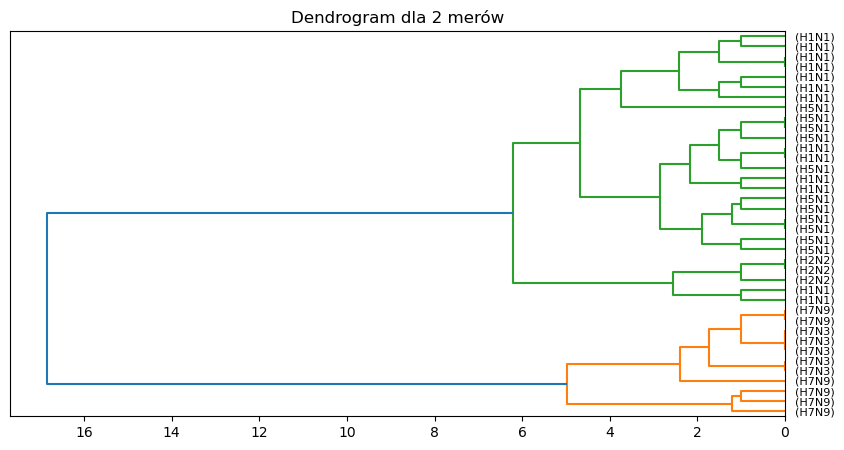

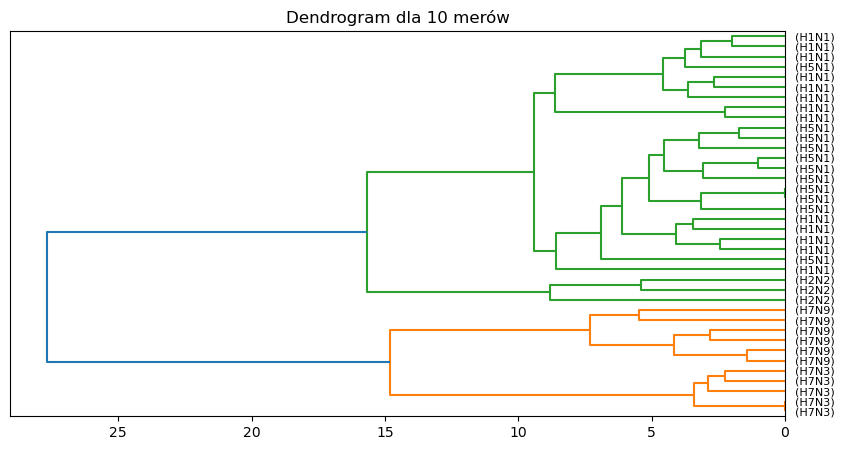

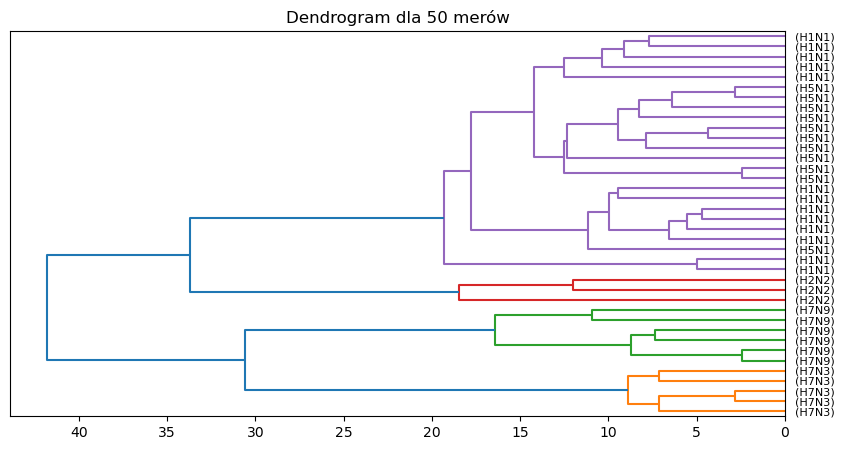

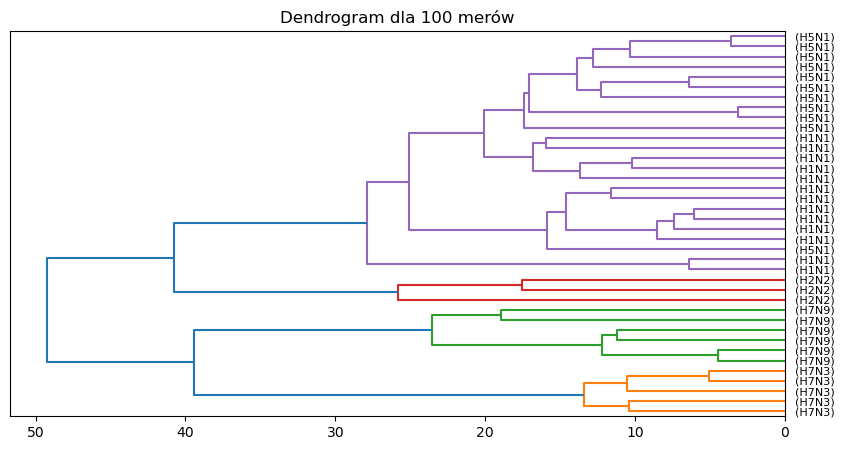

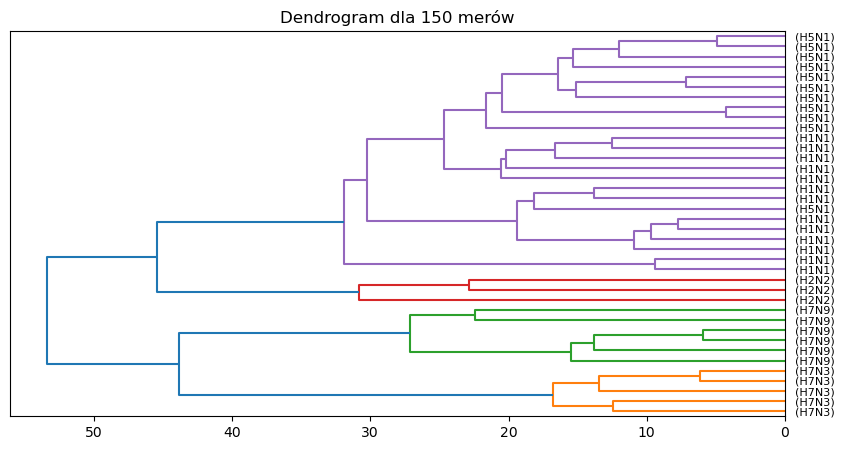

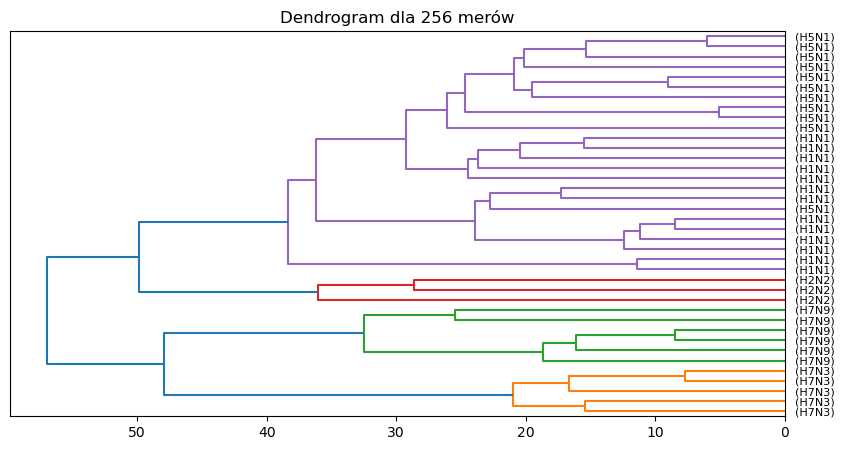

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
N = [2,10,50,100,150,256]
for n in N:
    top_kmers = stds.sort_values(ascending=False).head(n).index
    X = kmerki[top_kmers]

    linkage_data = linkage(X, method='average', metric='euclidean')
    plt.figure(figsize=(10, 5))
    dendrogram(linkage_data, orientation='left', labels=kmerki['virus_type'].values)
    plt.title(f'Dendrogram dla {n} merów')
    plt.show()

#comment
# N=[2,10] H7 distinguished
# N=[50,100,150,256] 3 groups distingushed